In [1]:
%cd /Users/work/Code/renewable-analysis/notebooks/computing_standard_energy_index

/Users/work/Code/renewable-analysis/notebooks/computing_standard_energy_index


In [2]:
import numpy as np
import pandas as pd
import xarray as xr
from scipy.stats import norm
from statsmodels.distributions.empirical_distribution import ECDF
import matplotlib.pyplot as plt

# Standard Energy Index (SEI) Computation

This notebook provides a general-purpose function for computing the Standard Energy Index (SEI) for any timeseries data, including:
- Renewable energy generation (PV, wind) - to identify low generation periods
- Energy demand - to identify high demand periods

The SEI uses an Empirical Cumulative Distribution Function (ECDF) approach with seasonal awareness (day-of-year) to standardize values into Z-scores.

**Reference**: https://www.sciencedirect.com/science/article/pii/S0960148123011217?via%3Dihub#d1e894

In [3]:
from sei_computation import compute_sei, compute_standardized_index, stack_doy_year_to_time

## Example Usage

Below are examples of how to use the `compute_sei` function with different types of data.

In [4]:
# Example of computing SEI from demand data

In [5]:
from renewable_data_load import *

In [6]:
# load and merge data from each region
peak_load_directory = "../../data/demand/DailyPeaks/"
# get list of csv files in directory
import os
csv_files = [f for f in os.listdir(peak_load_directory) if f.endswith('.csv')]

region_datasets = []  # Collect datasets with region names

for file in csv_files:
    region_name = file.split('_')[0]  # assuming the format is REGION_daily_peaks_reference_2025.csv
    df = pd.read_csv(os.path.join(peak_load_directory, file))
    df = df.rename(columns={'Date': 'time'})
    df.set_index('time', inplace=True)
    ds = df.to_xarray()
    
    # Add region name as coordinate
    ds = ds.expand_dims({'region': [region_name]})
    region_datasets.append(ds)

# Concatenate all regions with their names
peak_demand_ds = xr.concat(region_datasets, dim='region')

peak_demand_ds['time'] = pd.to_datetime(peak_demand_ds.time.values)
peak_demand_ds = peak_demand_ds.convert_calendar("noleap")

In [7]:
peak_demand_ds = peak_demand_ds.rename({'EC_EARTH3':'ec-earth3',
                                        'MIROC6':'miroc6',
                                        'MPI_ESM1_2_HR':'mpi-esm1-2-hr',
                                        'TAIESM1':'taiesm1'})

In [8]:
# get reference period of GWL 0.8 for each model

reference_period_ds = {}
reference_gwl = 0.8

for simulation in peak_demand_ds.data_vars:
    peak_demand_da = peak_demand_ds[simulation]

    # Get bounds for reference GWL period
    WRF_sim_name = sim_name_dict[simulation]
    model = WRF_sim_name.split("_")[1]
    ensemble_member = WRF_sim_name.split("_")[2]
    ref_start_year, ref_end_year = get_gwl_crossing_period(model, ensemble_member, reference_gwl)

    peak_demand_da = peak_demand_da.sel(time=slice(f"{ref_start_year}-01-01",f"{ref_end_year}-12-31"))

    reference_period_ds[simulation] = peak_demand_da

In [9]:
sim = 'mpi-esm1-2-hr'
sei = compute_sei(reference_period_ds[sim], peak_demand_ds[sim], window_size=60, fill_missing_year=True)

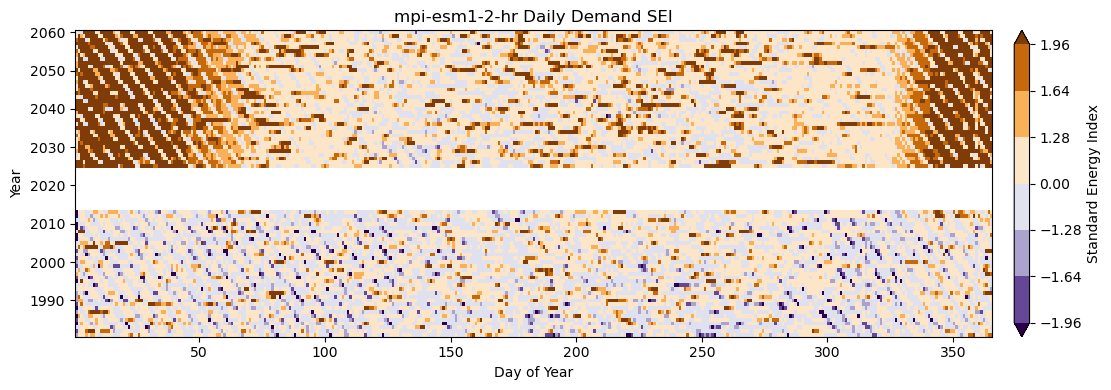

In [10]:
fig, ax = plt.subplots(figsize=(12,4))
xr.plot.imshow(sei.sel(region='PGE').T, ax=ax,levels=[-1.96, -1.64, -1.28, 0, 1.28, 1.64, 1.96], cmap="PuOr_r", cbar_kwargs={'pad': 0.02})
plt.title(f"{sim} Daily Demand SEI")
plt.ylabel("Year")
plt.xlabel("Day of Year")
plt.tight_layout()
plt.show()

In [13]:
sei_ts = stack_doy_year_to_time(sei)

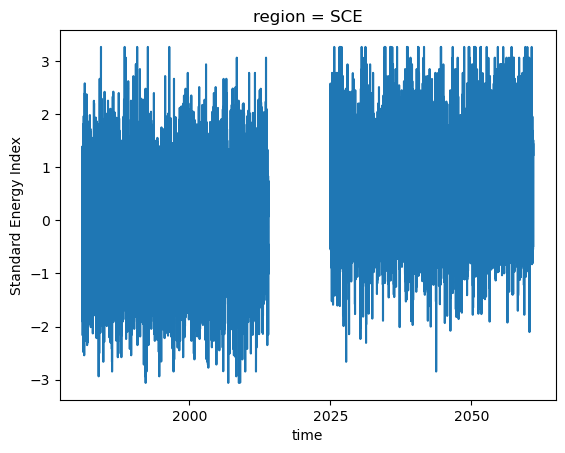

In [15]:
sei_ts.isel(region=0).plot()

In [ ]:
Example: Load and process renewable energy data

# Load your data (assuming already loaded as xarray DataArray)
historical_gen = xr.open_dataset("path/to/historical.nc")["generation"]
future_gen = xr.open_dataset("path/to/future.nc")["generation"]

# Ensure noleap calendar
historical_gen = historical_gen.convert_calendar("noleap")
future_gen = future_gen.convert_calendar("noleap")

# Compute SEI
sei = compute_sei(historical_gen, future_gen, window_size=30)

# Result has dimensions (year, dayofyear, ...)
print(sei)